In [1]:
import sys
import glob
import os
import pandas as pd

sys.path.insert(1, '../ProcessEvents/')
from config import CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, CATCHMENTS
from helper_functions import *
SOIL_TEXTURE_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/"
SOILS_LOOKUP_CSV = "../../Data/Rawls_soil_lookup.csv"  # USDA_soil, Hydraulic_conductivity

In [2]:
target_has = list(CATCHMENT_LOOKUP_DICT.keys())

from collections import Counter

texture_counts = Counter()

for tif in glob.glob(os.path.join(SOIL_TEXTURE_DIR, "*.tif")):
    ha_num = extract_ha_num(tif)
    if ha_num is None or ha_num not in target_has:
        continue

    with rasterio.open(tif) as src:
        data = src.read(1)
        valid = data != src.nodata

        values, counts = np.unique(data[valid], return_counts=True)
        texture_counts.update(dict(zip(values, counts)))

texture_counts_df = pd.DataFrame({"texture_class": list(texture_counts.keys()),"count": list(texture_counts.values())
}).sort_values("texture_class")

lookup = pd.read_csv(SOILS_LOOKUP_CSV)
texture_counts_df = texture_counts_df.merge(lookup[["USDA_soil", "Description"]],left_on="texture_class",
                                            right_on="USDA_soil",how="left").drop(columns="USDA_soil")
texture_counts_df

,texture_class,count,Description
0,0,9291037,none
1,1,24560593,clay
2,2,417810,silty clay
3,3,4330130,silty clay loam
4,5,2303244,sandy clay loam
5,6,55044844,clay loam
6,8,13138002,silt loam
7,9,91464030,loam
8,10,324408,sand
9,11,17122361,loamy sand


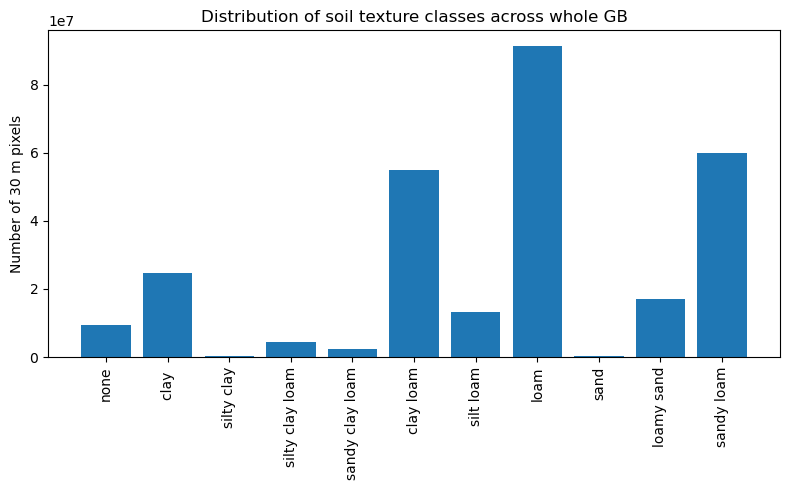

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(texture_counts_df["Description"].astype(str), texture_counts_df["count"])
ax.set_ylabel("Number of 30 m pixels")
ax.set_title("Distribution of soil texture classes across whole GB")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

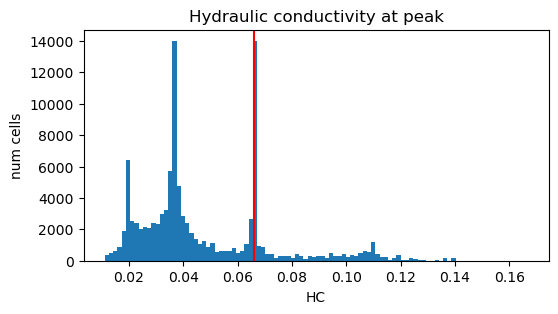

In [5]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments_added_soilvars.pkl"
rainfall_events_all_df = pd.read_pickle(fp)

fig,ax=plt.subplots(figsize=(6,3))
ax.hist(rainfall_events_all_df['lu_at_peak'], bins =100);
ax.set_title("Hydraulic conductivity at peak")
ax.set_ylabel("num cells");
ax.set_xlabel("HC");
ax.axvline(0.066, color='red')

In [7]:
rainfall_events_all_df["peak_cell_id"] = (rainfall_events_all_df["x_idx_global"].astype(str) + 
                                          "_"+ rainfall_events_all_df["y_idx_global"].astype(str))

In [8]:
# df: one row per event, with columns for peak grid cell id/coords and Lu at that cell
print(rainfall_events_all_df["lu_at_peak"].nunique())  # if small, strongly supports discrete-classes explanation

# Check whether spikes = repeated sampling of the same locations
spike_val = 0.037  # pick one of your spike locations
near_spike = rainfall_events_all_df[np.isclose(rainfall_events_all_df["lu_at_peak"], spike_val, atol=0.001)]

print(near_spike["peak_cell_id"].nunique(), "unique cells out of", len(near_spike), "events")
print(near_spike["peak_cell_id"].value_counts().head(10))

7726
1029 unique cells out of 15993 events
peak_cell_id
92_77    245
92_78    237
98_47    170
93_76    140
93_77    133
91_24    123
92_20    122
94_69    120
91_23    120
93_78    114
Name: count, dtype: int64
